To understand the effect of map product quality on PPI regression coefficient estimates, we simulate adding noise and bias to the map products from the forest cover linear regression example. We estimate linear regression coefficients for the association between forest cover in the contiguous United States and two covariates: elevation and population. We compare map-only, GT-only ("classical"), and PPI methods at different levels of noise and bias.

We experiment with adding noise or bias to the population map (error-in-X), the forest cover map (error-in-Y), or both (error-in-both). No error is added to the elevation dataset (we use ground truth elevation data rather than a map product). 

Map product points and ground truth points are both from MOSAIKS paper dataset (Rolf et al, 2021): https://github.com/Global-Policy-Lab/mosaiks-paper

In [36]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.weightstats import _zconfint_generic
import statsmodels
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import r2_score

# PPI for linear regression

The code for PPI for linear regression, as described in Section 2.2 of the paper, is given below. (The same code is used in all three of our linear regression notebooks.)

The main function is **bootstrap_ppi** which gives 100*(1-alpha) percent PPI confidence intervals for the regression coefficients. X and Y are the ground truth covariates and outcomes (respectively), Xhat and Yhat are the remotely sensed covariates and outcomes at the same locations as the ground truth, and Xhat_unlabeled and Yhat_unlabeled are a larger dataset of remotely sensed covariates and outcomes that do not have corresponding ground truth values available. 

Additionally, **classical_ols_ci** computes the 100*(1-alpha) percent GT-only confidence intervals.

In [26]:
def ppi_pointestimate(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, tuning_matrix):
    coeff_calibration = OLS(Y, exog=statsmodels.tools.add_constant(X)).fit().params
    coeff_preds_calibration = OLS(Yhat, exog=statsmodels.tools.add_constant(Xhat)).fit().params
    coeff_preds_all = OLS(Yhat_unlabeled, exog=statsmodels.tools.add_constant(Xhat_unlabeled)).fit().params
    
    coeff_ppi = tuning_matrix @ coeff_preds_all + (coeff_calibration - tuning_matrix @ coeff_preds_calibration)
    
    return coeff_ppi
    
def cross_cov(A, B):
    '''
    A is (p x n)
    B is (p x n)
    
    Output: (p x p) cross-covariance matrix
    '''
    n = A.shape[1]
    C = 1/(n-1) * (A-A.mean(axis=1)[:, np.newaxis]) @ (B-B.mean(axis=1)[:, np.newaxis]).T
    return C

def resample_datapoints(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled):
    # resample datapoints for a single bootstrap trial
    calibration_indices = np.random.choice(np.arange(0, len(X)), size=len(X), replace=True)
    preds_indices = np.random.choice(np.arange(0, len(Xhat_unlabeled)), size=len(Xhat_unlabeled), replace=True)

    X_trial = X[calibration_indices]
    Xhat_trial = Xhat[calibration_indices]
    Xhat_unlabeled_trial = Xhat_unlabeled[preds_indices]
    Y_trial = Y[calibration_indices]
    Yhat_trial = Yhat[calibration_indices]
    Yhat_unlabeled_trial = Yhat_unlabeled[preds_indices]
    
    return X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial

def bootstrap_ppi(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, tune=True, trials=100, alpha=0.05):
    
    if tune:
        # bootstrap to get tuning matrix
        coeff_calibration_list = []
        coeff_preds_calibration_list = []
        for trial in tqdm(range(trials)):
            X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial = resample_datapoints(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled)

            coeff_calibration = OLS(Y_trial, exog=statsmodels.tools.add_constant(X_trial)).fit().params
            coeff_calibration_list.append(coeff_calibration)

            coeff_preds_calibration = OLS(Yhat_trial, exog=statsmodels.tools.add_constant(Xhat_trial)).fit().params
            coeff_preds_calibration_list.append(coeff_preds_calibration)

        coeff_calibration_list = np.array(coeff_calibration_list).T
        coeff_preds_calibration_list = np.array(coeff_preds_calibration_list).T

        tuning_matrix = cross_cov(coeff_calibration_list, coeff_preds_calibration_list) @ np.linalg.inv(np.cov(coeff_preds_calibration_list))
    else:
        tuning_matrix = np.identity(X.shape[1]+1)
    
    # bootstrap to get confidence interval for coefficient
    outputs = []
    for trial in tqdm(range(trials)):
        X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial = resample_datapoints(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled)
        
        output = ppi_pointestimate(X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial, tuning_matrix)
        outputs.append(output)
        
    lo = np.percentile(outputs, 100*alpha/2, axis=0)
    hi = np.percentile(outputs, 100*(1-alpha/2), axis=0)
    return (lo, hi)

def classical_ols_ci(X, Y, alpha, alternative="two-sided"):
    regression = OLS(Y, exog=statsmodels.tools.add_constant(X)).fit()
    theta = regression.params
    se = regression.HC0_se
    ci = _zconfint_generic(theta, se, alpha, alternative)
    return (ci[0], ci[1])

# Load data

Load MOSAIKS datasets for forest cover, elevation, and population. After dropping points with missing variables, there are N=67968 total points. Each point has both ground truth and map product values in the original dataset.

For elevation, we will use ground truth data at all points. For forest cover and population, we will create simulated map products at different levels of noise and bias (along with a small calibration set of points with both ground truth and simulated map product values).

In [27]:
file_path = "data/MOSAIKS/outcomes_scatter_obsAndPred_treecover_treecover_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
tree_data = pd.DataFrame.from_dict(data, orient='index').T

file_path = "data/MOSAIKS/outcomes_testset_obsAndPred_treecover_treecover_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
data = pd.DataFrame.from_dict(data, orient='index').T
tree_data = pd.concat([tree_data, data])

tree_data = tree_data.rename(columns={"truth": "truth_tree", "preds": "preds_tree"})
tree_data = tree_data[['truth_tree', 'preds_tree', 'lon', 'lat']]

In [28]:
file_path = "data/MOSAIKS/outcomes_scatter_obsAndPred_elevation_meters_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
elevation_data = pd.DataFrame.from_dict(data, orient='index').T

file_path = "data/MOSAIKS/outcomes_testset_obsAndPred_elevation_meters_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
data = pd.DataFrame.from_dict(data, orient='index').T
elevation_data = pd.concat([elevation_data, data])

elevation_data = elevation_data.rename(columns={"truth": "truth_elevation", "preds": "preds_elevation"})
elevation_data = elevation_data[['truth_elevation', 'preds_elevation', 'lon', 'lat']]

In [29]:
file_path = "data/MOSAIKS/outcomes_scatter_obsAndPred_population_log_population_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
population_data = pd.DataFrame.from_dict(data, orient='index').T

file_path = "data/MOSAIKS/outcomes_testset_obsAndPred_population_log_population_CONTUS_16_640_UAR_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
data = pd.DataFrame.from_dict(data, orient='index').T
population_data = pd.concat([population_data, data])

population_data = population_data.rename(columns={"truth": "truth_population", "preds": "preds_population"})
population_data = population_data[['truth_population', 'preds_population', 'lon', 'lat']]

In [30]:
data = pd.merge(tree_data, elevation_data, on=['lon', 'lat'])
data = pd.merge(data, population_data, on=['lon', 'lat'])

In [31]:
# convert from m to km
data['truth_elevation'] = .001*data['truth_elevation']
data['preds_elevation'] = .001*data['preds_elevation']

In [32]:
data

,truth_tree,preds_tree,lon,lat,truth_elevation,preds_elevation,truth_population,preds_population
0,0.000000,0.000000,-119.794019,46.773157,0.423914,0.963784,0.290985,0.223613
1,0.000000,0.000000,-107.440142,36.628412,2.015408,1.779982,0.070059,1.089495
2,32.511176,42.111039,-87.580287,30.316254,0.005059,-0.016801,1.771785,2.923414
3,1.706111,0.000000,-102.316795,43.250483,1.000075,1.164283,2.654329,0.872536
4,34.121974,38.179145,-97.661712,29.815675,0.144380,0.310666,1.539581,1.788519
...,...,...,...,...,...,...,...,...
67963,0.056365,11.829323,-99.741350,32.537026,0.521323,0.422672,3.776049,3.563149
67964,1.926316,8.442633,-83.352149,41.014260,0.256471,0.174457,3.064954,2.710515
67965,2.947000,0.000000,-86.850348,36.650512,0.169112,0.125459,4.120613,3.165970
67966,0.084062,7.715938,-99.906619,31.509565,0.495074,0.488693,0.945092,1.091228


In [33]:
truth_Y = np.array(data['truth_tree']).reshape(-1, 1)
truth_X = np.array(data[['truth_elevation', 'truth_population']])

map_Y = np.array(data['preds_tree']).reshape(-1, 1)
map_X = np.array(data[['truth_elevation', 'preds_population']])

# TRUE THETA
true_coeff = OLS(truth_Y, exog=statsmodels.tools.add_constant(truth_X)).fit().params
print(true_coeff)

[ 31.80598858 -12.25842547   1.37923979]


# Add noise

To create a simulated noisy map product, we add zero-centered Gaussian noise to ground truth population (X), forest cover (Y), or both. We vary the standard deviation of the Gaussian noise from zero to the standard deviation of the corresponding variable (X or Y). For more detail, see our paper. 

We print out the GT-only (classical), map-only, and PPI estimates and confidence interval widths. We also print the R^2 coefficient of determination between the simulated map product and the ground truth. 

In [37]:
def run_ppi_linear_regression(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, alpha):
    results = []

    # Prediction-Powered Inference
    ppi_ci = bootstrap_ppi(
        X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, trials=200, alpha=alpha
    )
    # Append results
    results += [
        pd.DataFrame(
            [
                {
                    "method": "PPI",
                    "n": np.nan,
                    "lower": ppi_ci[0],
                    "upper": ppi_ci[1],
                    "trial": np.nan,
                }
            ]
        )
    ]
    
    # Map-only CI
    map_only_ci = classical_ols_ci(Xhat_unlabeled, Yhat_unlabeled, alpha=alpha)
    results += [
        pd.DataFrame(
            [
                {
                    "method": "Map-only",
                    "n": np.nan,
                    "lower": map_only_ci[0],
                    "upper": map_only_ci[1],
                    "trial": 0,
                }
            ]
        )
    ]

    df = pd.concat(results, axis=0, ignore_index=True)
    df["width"] = df["upper"] - df["lower"]
    df["estimate"] = 0.5*(df["upper"] + df["lower"])
    return df

In [38]:
plt.rcParams["font.sans-serif"] = "Arial"

plt.rc('font', size=32)          
plt.rc('axes', titlesize=32)     
plt.rc('axes', labelsize=32)    
plt.rc('xtick', labelsize=32)    
plt.rc('ytick', labelsize=32)    
plt.rc('legend', fontsize=32)    
plt.rc('figure', titlesize=32)

Classical estimate then width:
[ 33.60350517 -13.98925325   0.29617747]
[11.72985261  9.68382557  3.08682222]
ERROR IN X:


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 54.57it/s]


c: 0.0 | R2 X: 1.0 | R2 Y: 1.0 | PPI estimates: [ 31.84321405 -12.2750384    1.38824736] | PPI widths: [0.99753417 0.68284876 0.25011362] | Map-only estimates: [ 31.80598858 -12.25842547   1.37923979] | Map-only widths: [1.02454054 0.7501571  0.28631906]


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 58.32it/s]


c: 0.1 | R2 X: 0.994998374325837 | R2 Y: 1.0 | PPI estimates: [ 32.28101068 -12.46448768   1.17070896] | PPI widths: [1.39703776 0.93228315 0.50815755] | Map-only estimates: [ 31.86220357 -12.28576622   1.35725041] | Map-only widths: [1.02020014 0.7488896  0.28421387]


...

c: 0.8 | R2 X: 0.6812099354169634 | R2 Y: 0.3581183057165289 | PPI estimates: [ 35.16007967 -14.93746744  -0.07259907] | PPI widths: [7.97814929 5.32822938 2.45356238] | Map-only estimates: [ 33.51244817 -13.22745772   0.73974703] | Map-only widths: [1.13949716 0.95903258 0.28419572]


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 44.08it/s]


c: 0.9 | R2 X: 0.5906796913381465 | R2 Y: 0.18950231458252087 | PPI estimates: [ 32.25442064 -13.25153362   0.66560132] | PPI widths: [9.16243087 6.90157972 2.88073666] | Map-only estimates: [ 33.3216398  -13.05072618   0.71878318] | Map-only widths: [1.15761716 1.00773593 0.28322822]


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 50.33it/s]


c: 1.0 | R2 X: 0.5013635897443656 | R2 Y: 0.007268850273323024 | PPI estimates: [ 33.23026782 -12.77938086   0.41920075] | PPI widths: [9.75190964 7.33469693 2.95792555] | Map-only estimates: [ 33.69081453 -13.14976474   0.57462471] | Map-only widths: [1.19733501 1.05009223 0.28492349]


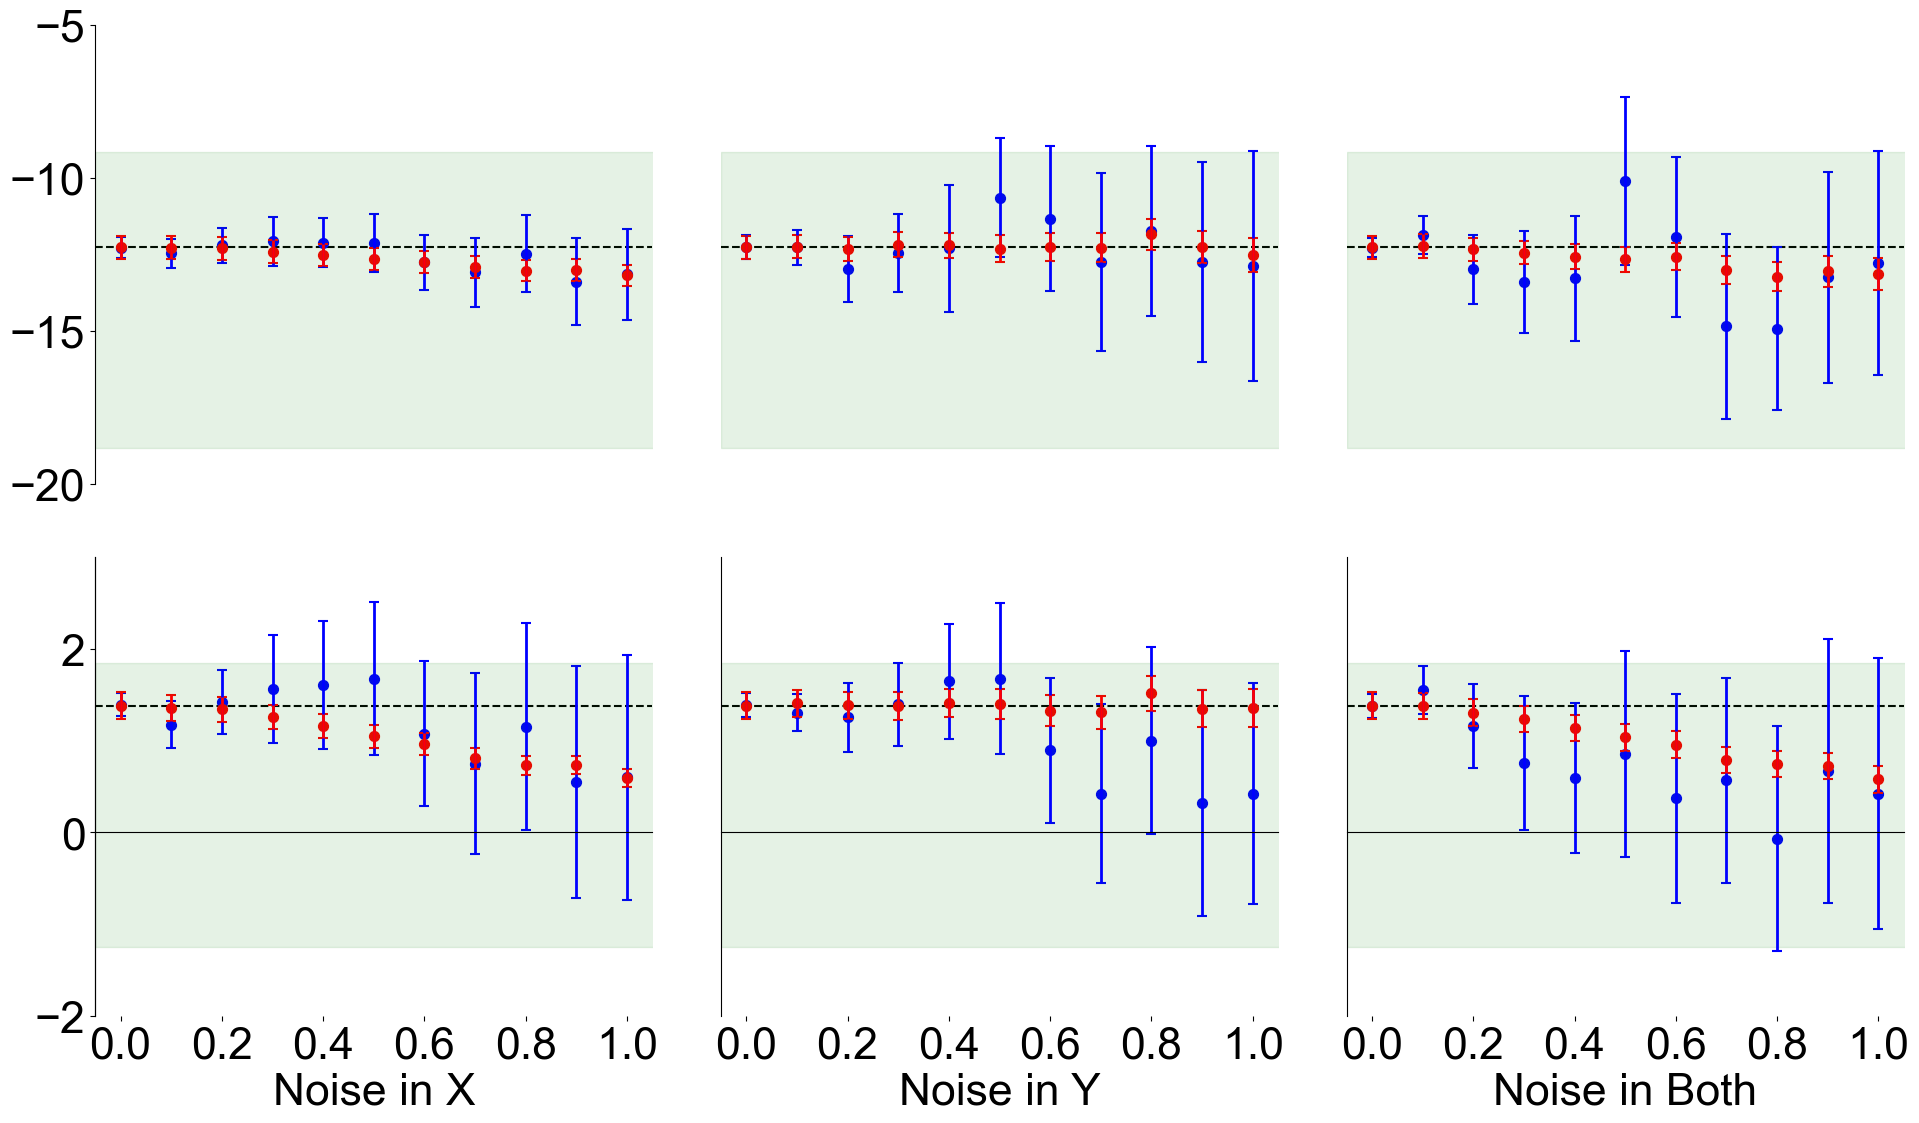

In [43]:
noise_factors = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
#noise_factors = np.array([0])
alpha = 0.05

# Classical CI
np.random.seed(seed=0)
calibration_indices = np.random.choice(np.arange(0, len(data)), size=500, replace=True)
X = truth_X[calibration_indices]
Y = truth_Y[calibration_indices]
classical_ci = classical_ols_ci(X, Y, alpha=alpha)
classical_estimate = 0.5*(classical_ci[0] + classical_ci[1])
classical_width = (classical_ci[1] - classical_ci[0])
print("Classical estimate then width:")
print(classical_estimate)
print(classical_width)

X_std = np.std(truth_X, axis=0)[-1] # standard deviation of population covariate
Y_std = np.std(truth_Y, axis=0)

fig = plt.figure(figsize=(20, 12))
for j, error_mode in enumerate(['X', 'Y', 'Both']):
    print(f"ERROR IN {error_mode}:")
    ppi_estimates = []
    ppi_widths = []
    map_only_estimates = []
    map_only_widths = []

    for noise_factor in noise_factors:
        preds_X = truth_X.copy()
        preds_X[:, -1] = truth_X[:, -1] + np.random.normal(0, noise_factor*X_std, size=len(truth_X))

        preds_Y = truth_Y[:, 0] + np.random.normal(0, noise_factor*Y_std, size=len(truth_Y))
        
        if error_mode == 'X':
            # ERROR IN X
            Xhat = preds_X[calibration_indices]
            Xhat_unlabeled = preds_X
            Yhat = truth_Y[calibration_indices]
            Yhat_unlabeled = truth_Y
        if error_mode == 'Y':
            # ERROR IN Y
            Xhat = truth_X[calibration_indices]
            Xhat_unlabeled = truth_X
            Yhat = preds_Y[calibration_indices]
            Yhat_unlabeled = preds_Y
        if error_mode == 'Both':
            # ERROR IN Both
            Xhat = preds_X[calibration_indices]
            Xhat_unlabeled = preds_X
            Yhat = preds_Y[calibration_indices]
            Yhat_unlabeled = preds_Y
            
        df = run_ppi_linear_regression(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, alpha)
        ppi_estimates.append(df.loc[df['method']=='PPI']['estimate'].mean())
        ppi_widths.append(df.loc[df['method']=='PPI']['width'].mean())
        map_only_estimates.append(df.loc[df['method']=='Map-only']['estimate'].mean())
        map_only_widths.append(df.loc[df['method']=='Map-only']['width'].mean())
        
        print("c:", noise_factor,
              "| R2 X:", r2_score(truth_X, Xhat_unlabeled),
              "| R2 Y:", r2_score(truth_Y, Yhat_unlabeled),
              "| PPI estimates:", ppi_estimates[-1], "| PPI widths:", ppi_widths[-1], 
              "| Map-only estimates:", map_only_estimates[-1], "| Map-only widths:", map_only_widths[-1])
    
    ppi_estimates = np.array(ppi_estimates)
    ppi_widths = np.array(ppi_widths)
    map_only_estimates = np.array(map_only_estimates)
    map_only_widths = np.array(map_only_widths)
    
    for k in [1, 2]:
        subplot = fig.add_subplot(231+j+3*(k-1))
        #ax = plt.gca()
        subplot.spines['top'].set_visible(False)
        subplot.spines['right'].set_visible(False)

        subplot.axhline(true_coeff[k], color ='black', linestyle='--', label='True coefficient', zorder=0)

        subplot.plot([], '-o', color='blue', label='PPI')
        subplot.plot([], '-o', color='red', label='Map-only')

        for i, prob in enumerate(noise_factors):
            ymin = (ppi_estimates[:, k]-np.array(ppi_widths[:, k])/2)[i]
            ymax = (ppi_estimates[:, k]+np.array(ppi_widths[:, k])/2)[i]
            subplot.vlines(x=prob, ymin=ymin, ymax=ymax, color="blue", linewidth=2)
        subplot.scatter(noise_factors, ppi_estimates[:, k], color='blue', s=50)
        subplot.scatter(noise_factors, ppi_estimates[:, k]-np.array(ppi_widths[:, k])/2, color='blue', marker='_', s=50)
        subplot.scatter(noise_factors, ppi_estimates[:, k]+np.array(ppi_widths[:, k])/2, color='blue', marker='_', s=50)

        for i, prob in enumerate(noise_factors):
            ymin = (map_only_estimates[:, k]-np.array(map_only_widths[:, k])/2)[i]
            ymax = (map_only_estimates[:, k]+np.array(map_only_widths[:, k])/2)[i]
            subplot.vlines(x=prob, ymin=ymin, ymax=ymax, color="red", linewidth=2)
        subplot.scatter(noise_factors, map_only_estimates[:, k], color='red', s=50)
        subplot.scatter(noise_factors, map_only_estimates[:, k]-np.array(map_only_widths[:, k])/2, color='red', marker='_', s=50)
        subplot.scatter(noise_factors, map_only_estimates[:, k]+np.array(map_only_widths[:, k])/2, color='red', marker='_', s=50)

        subplot.fill_between(np.arange(-0.05, 1.2, 0.1), classical_estimate[k]-classical_width[k]/2, classical_estimate[k]+classical_width[k]/2, color='green', alpha=0.1, label='GT-only')

        #plt.legend(bbox_to_anchor=(1.5, 1.5))
        
        subplot.set_xlim([-0.05, 1.05])
        if k==2: # population
            subplot.set_xticks(np.arange(0, 1.05, 0.2))
            subplot.set_ylim([-2, 3])
            subplot.set_yticks(np.arange(-2, 3, 2))
            subplot.set_xlabel(f"Noise in {error_mode}")
            
            subplot.spines['bottom'].set_visible(False)
            ax = subplot.twiny()
            ax.spines['bottom'].set_position(('data', 0))
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_xticks([])
            
        else:
            subplot.set_ylim([-20, -5])
            subplot.set_yticks(np.arange(-20, -4, 5))
            subplot.spines['bottom'].set_visible(False)
            subplot.set_xticks([])
            
        if j!=0:
            subplot.spines['left'].set_visible(False)
            subplot.yaxis.set_visible(False)
        
        '''
        if j==0:
            if k==1:
                subplot.set_ylabel("Elevation Coeff")
            else:
                subplot.set_ylabel("Population Coeff")
        else:
            subplot.spines['left'].set_visible(False)
            subplot.yaxis.set_visible(False)
        '''

plt.tight_layout()
plt.savefig('output_images/forest_cover_noise.png', dpi=300, bbox_inches='tight')
plt.show()

# Add bias (mean reversion)

To create a simulated map product with mean reversion bias, we linearly interpolate between the ground truth value of a variable and the mean of all ground truth values for that variable. We vary the linear interpolation parameter to control the amount of bias. We do this for population (X), forest cover (Y), or both. For more detail, see the appendix of our paper. 

We print out the GT-only (classical), map-only, and PPI estimates and confidence interval widths. We also print the R^2 coefficient of determination between the simulated map product and the ground truth. 

Classical estimate then width:
[ 33.60350517 -13.98925325   0.29617747]
[11.72985261  9.68382557  3.08682222]


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 50.99it/s]


X
PPI estimates then widths:
[[ 31.80043704 -12.24495648   1.38488822]
 [ 31.76049792 -12.24091694   1.38104132]
 [ 31.81719223 -12.31351728   1.37283317]
 [ 31.89678681 -12.26825884   1.36898595]
 [ 31.84969004 -12.29857049   1.37211189]
 [ 31.8051021  -12.2589672    1.39762797]
 [ 31.81960622 -12.23162115   1.37547017]
 [ 31.76929645 -12.24967249   1.38794677]
 [ 31.79121467 -12.24802729   1.35859255]]
[[0.99985565 0.70883929 0.25424586]
 [0.98291684 0.68429486 0.26307028]
 [1.03353758 0.68507396 0.30417959]
 [1.08247037 0.70962174 0.27326168]
 [1.02642267 0.71684444 0.30278425]
 [0.95302817 0.65724557 0.28485995]
 [0.94395937 0.5899865  0.26840476]
 [0.93560508 0.71763433 0.25516216]
 [0.88697042 0.71555932 0.29515084]]
Map only estimates then widths:
[[ 31.80598858 -12.25842547   1.37923979]
 [ 31.53761854 -12.25842547   1.53248865]
 [ 31.20215599 -12.25842547   1.72404974]
 [ 30.770847   -12.25842547   1.97034255]
 [ 30.19576834 -12.25842547   2.29873298]
 [ 29.39065823 -12.258425

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 45.84it/s]


Y
PPI estimates then widths:
[[ 31.75228061 -12.23941498   1.39653272]
 [ 31.78374958 -12.25651871   1.38388703]
 [ 31.7681106  -12.2612145    1.39390739]
 [ 31.75537214 -12.24198629   1.38496444]
 [ 31.81562299 -12.2645931    1.37412455]
 [ 31.77799859 -12.30572965   1.39812704]
 [ 31.75848098 -12.22807264   1.38848616]
 [ 31.83217193 -12.24807097   1.37877753]
 [ 31.72393505 -12.22761753   1.38600827]]
[[1.01541262 0.71745792 0.28544065]
 [1.07955764 0.84560245 0.28629119]
 [0.98669615 0.6927423  0.26888102]
 [1.15960647 0.85921612 0.26937133]
 [0.84835259 0.70888436 0.26485552]
 [0.88732402 0.69881797 0.28171624]
 [1.00954858 0.73838095 0.26803393]
 [0.97316114 0.71236623 0.27634333]
 [0.89142682 0.73563331 0.24430944]]
Map only estimates then widths:
[[ 31.80598858 -12.25842547   1.37923979]
 [ 31.78460001 -11.03258293   1.24131581]
 [ 31.76321144  -9.80674038   1.10339183]
 [ 31.74182287  -8.58089783   0.96546785]
 [ 31.7204343   -7.35505528   0.82754387]
 [ 31.69904573  -6.129212

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 52.10it/s]


Both
PPI estimates then widths:
[[ 31.79167934 -12.30159316   1.38696264]
 [ 31.77776192 -12.26860892   1.38321847]
 [ 31.81690976 -12.28497374   1.37526447]
 [ 31.83419899 -12.23089236   1.36815698]
 [ 31.77691888 -12.23932504   1.38553444]
 [ 31.77838563 -12.26893659   1.37315393]
 [ 31.75682061 -12.19726217   1.38159442]
 [ 31.7963531  -12.27427819   1.37351739]
 [ 31.78036479 -12.25093281   1.37467467]]
[[1.0197077  0.88415324 0.29783704]
 [1.00400458 0.76809636 0.2835962 ]
 [1.09805996 0.74390757 0.26811695]
 [1.01143995 0.69916205 0.28872721]
 [1.09696618 0.67905067 0.2832796 ]
 [0.99258944 0.7048156  0.27877142]
 [1.03660714 0.75417809 0.28414299]
 [1.06336814 0.76505098 0.29855367]
 [1.07628016 0.72911934 0.28465166]]
Map only estimates then widths:
[[ 31.80598858 -12.25842547   1.37923979]
 [ 31.54306697 -11.03258293   1.37923979]
 [ 31.28014537  -9.80674038   1.37923979]
 [ 31.01722377  -8.58089783   1.37923979]
 [ 30.75430216  -7.35505528   1.37923979]
 [ 30.49138056  -6.129

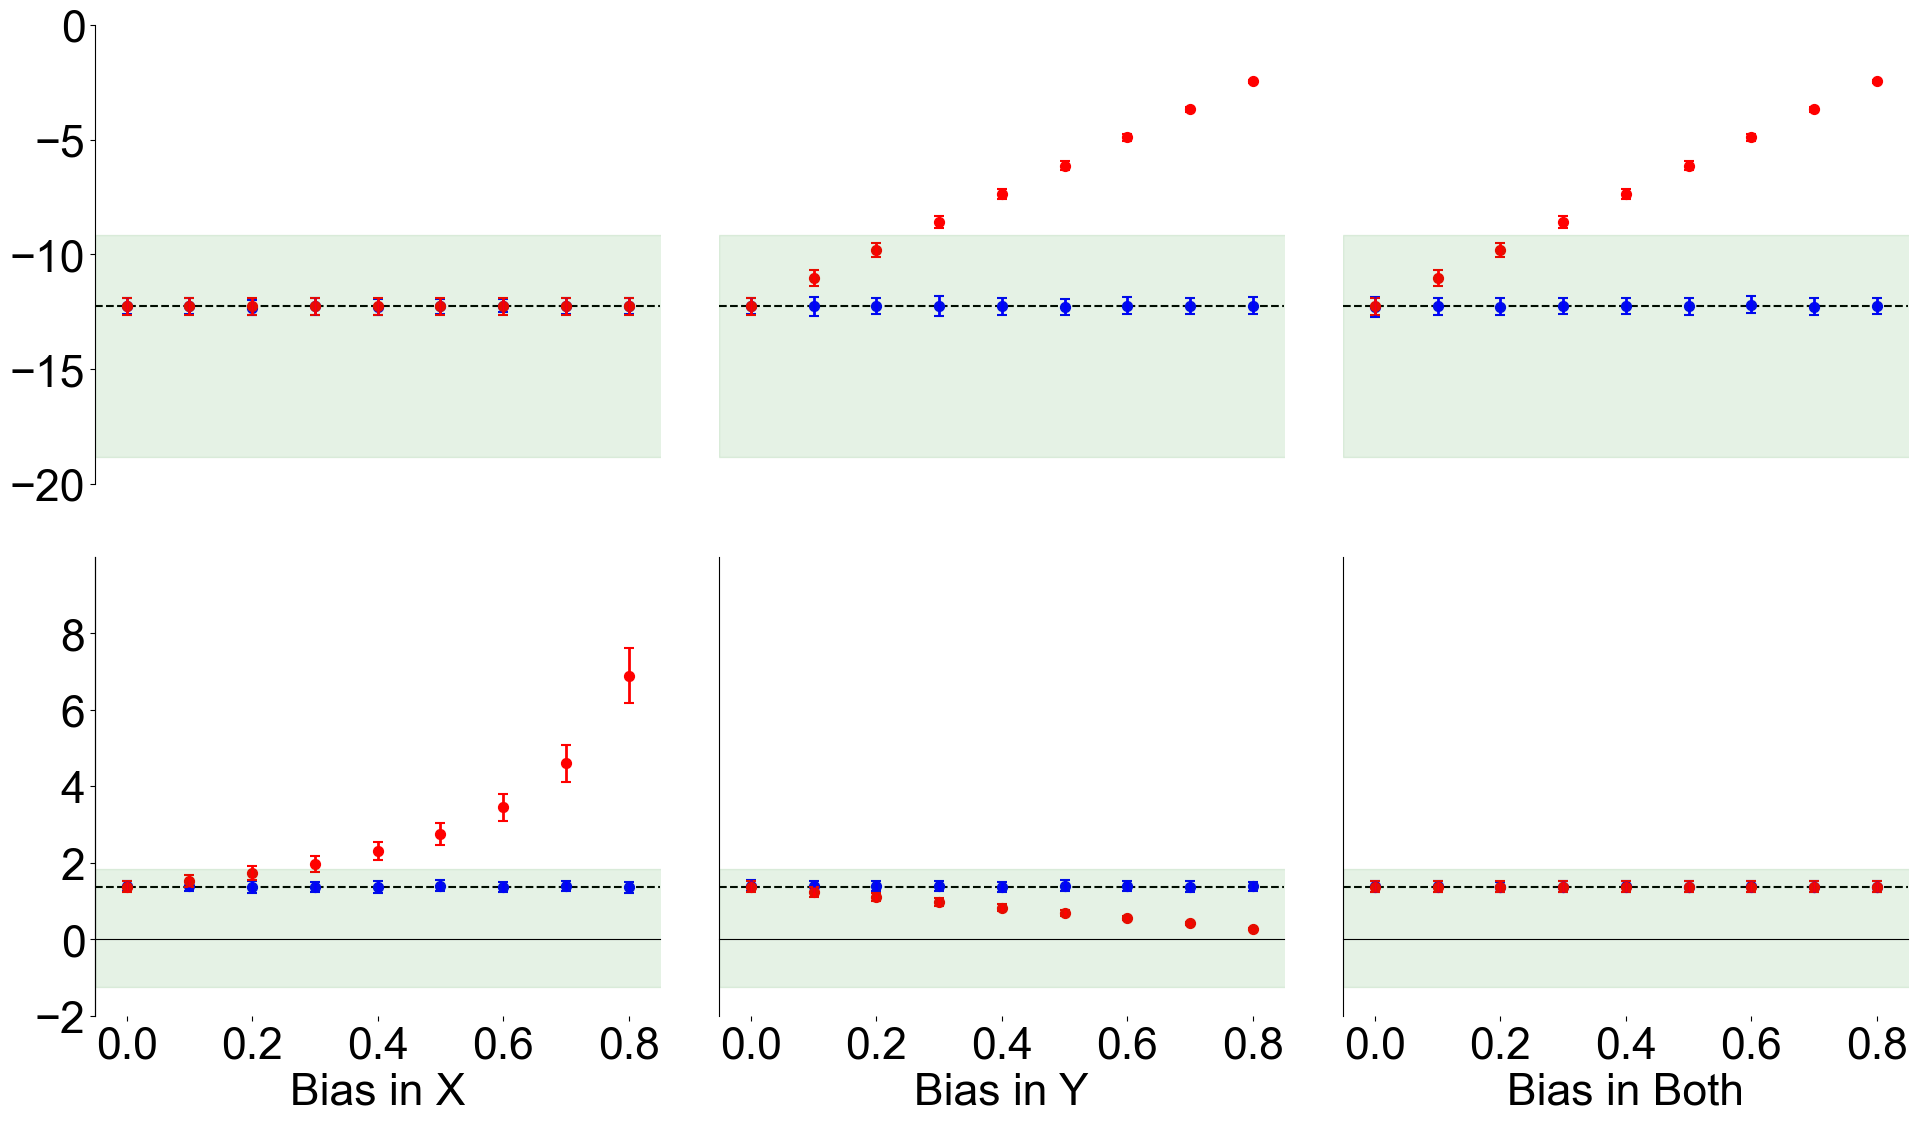

In [13]:
bias_factors = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
#bias_factors = np.array([0])
alpha = 0.05

# Classical CI
np.random.seed(seed=0)
calibration_indices = np.random.choice(np.arange(0, len(data)), size=500, replace=True)
X = truth_X[calibration_indices]
Y = truth_Y[calibration_indices]
classical_ci = classical_ols_ci(X, Y, alpha=alpha)
classical_estimate = 0.5*(classical_ci[0] + classical_ci[1])
classical_width = (classical_ci[1] - classical_ci[0])
print("Classical estimate then width:")
print(classical_estimate)
print(classical_width)

X_mean = np.mean(truth_X, axis=0)[-1] # mean of population covariate
Y_mean = np.std(truth_Y, axis=0)

fig = plt.figure(figsize=(20, 12))
for j, error_mode in enumerate(['X', 'Y', 'Both']):
    ppi_estimates = []
    ppi_widths = []
    map_only_estimates = []
    map_only_widths = []

    for bias_factor in bias_factors:
        preds_X = truth_X.copy()
        preds_X[:, -1] = bias_factor*X_mean + (1-bias_factor)*truth_X[:, -1]

        preds_Y = bias_factor*Y_mean + (1-bias_factor)*truth_Y[:, 0]
        
        if error_mode == 'X':
            # ERROR IN X
            Xhat = preds_X[calibration_indices]
            Xhat_unlabeled = preds_X
            Yhat = truth_Y[calibration_indices]
            Yhat_unlabeled = truth_Y
        if error_mode == 'Y':
            # ERROR IN Y
            Xhat = truth_X[calibration_indices]
            Xhat_unlabeled = truth_X
            Yhat = preds_Y[calibration_indices]
            Yhat_unlabeled = preds_Y
        if error_mode == 'Both':
            # ERROR IN Both
            Xhat = preds_X[calibration_indices]
            Xhat_unlabeled = preds_X
            Yhat = preds_Y[calibration_indices]
            Yhat_unlabeled = preds_Y
            
        df = run_ppi_linear_regression(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, alpha)
        ppi_estimates.append(df.loc[df['method']=='PPI']['estimate'].mean())
        ppi_widths.append(df.loc[df['method']=='PPI']['width'].mean())
        map_only_estimates.append(df.loc[df['method']=='Map-only']['estimate'].mean())
        map_only_widths.append(df.loc[df['method']=='Map-only']['width'].mean())
    
    ppi_estimates = np.array(ppi_estimates)
    ppi_widths = np.array(ppi_widths)
    map_only_estimates = np.array(map_only_estimates)
    map_only_widths = np.array(map_only_widths)
    print(error_mode)
    print("PPI estimates then widths:")
    print(ppi_estimates)
    print(ppi_widths)
    print("Map only estimates then widths:")
    print(map_only_estimates)
    print(map_only_widths)
    
    for k in [1, 2]:
        subplot = fig.add_subplot(231+j+3*(k-1))
        #ax = plt.gca()
        subplot.spines['top'].set_visible(False)
        subplot.spines['right'].set_visible(False)

        subplot.axhline(true_coeff[k], color ='black', linestyle='--', label='True coefficient', zorder=0)

        subplot.plot([], '-o', color='blue', label='PPI')
        subplot.plot([], '-o', color='red', label='Map-only')

        for i, prob in enumerate(bias_factors):
            ymin = (ppi_estimates[:, k]-np.array(ppi_widths[:, k])/2)[i]
            ymax = (ppi_estimates[:, k]+np.array(ppi_widths[:, k])/2)[i]
            subplot.vlines(x=prob, ymin=ymin, ymax=ymax, color="blue", linewidth=2)
        subplot.scatter(bias_factors, ppi_estimates[:, k], color='blue', s=50)
        subplot.scatter(bias_factors, ppi_estimates[:, k]-np.array(ppi_widths[:, k])/2, color='blue', marker='_', s=50)
        subplot.scatter(bias_factors, ppi_estimates[:, k]+np.array(ppi_widths[:, k])/2, color='blue', marker='_', s=50)

        for i, prob in enumerate(bias_factors):
            ymin = (map_only_estimates[:, k]-np.array(map_only_widths[:, k])/2)[i]
            ymax = (map_only_estimates[:, k]+np.array(map_only_widths[:, k])/2)[i]
            subplot.vlines(x=prob, ymin=ymin, ymax=ymax, color="red", linewidth=2)
        subplot.scatter(bias_factors, map_only_estimates[:, k], color='red', s=50)
        subplot.scatter(bias_factors, map_only_estimates[:, k]-np.array(map_only_widths[:, k])/2, color='red', marker='_', s=50)
        subplot.scatter(bias_factors, map_only_estimates[:, k]+np.array(map_only_widths[:, k])/2, color='red', marker='_', s=50)

        subplot.fill_between(np.arange(-0.05, 1.2, 0.1), classical_estimate[k]-classical_width[k]/2, classical_estimate[k]+classical_width[k]/2, color='green', alpha=0.1, label='GT-only')

        #plt.legend(bbox_to_anchor=(1.5, 1.5))
        
        subplot.set_xlim([-0.05, .85])
        if k==2: # population
            subplot.set_xticks(np.arange(0, .85, 0.2))
            subplot.set_ylim([-2, 10])
            subplot.set_yticks(np.arange(-2, 10, 2))
            subplot.set_xlabel(f"Bias in {error_mode}")
            
            subplot.spines['bottom'].set_visible(False)
            ax = subplot.twiny()
            ax.spines['bottom'].set_position(('data', 0))
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_xticks([])
            
        else:
            subplot.set_ylim([-20, 0])
            subplot.set_yticks(np.arange(-20, 1, 5))
            subplot.spines['bottom'].set_visible(False)
            subplot.set_xticks([])
            
        if j!=0:
            subplot.spines['left'].set_visible(False)
            subplot.yaxis.set_visible(False)
        
        '''
        if j==0:
            if k==1:
                subplot.set_ylabel("Elevation Coeff")
            else:
                subplot.set_ylabel("Population Coeff")
        else:
            subplot.spines['left'].set_visible(False)
            subplot.yaxis.set_visible(False)
        '''

plt.tight_layout()
plt.savefig('output_images/forest_cover_bias.png', dpi=300, bbox_inches='tight')
plt.show()

# Add bias (quadratic fit)

We explore another type of bias. We first fit a quadratic regression relating a variable to its corresponding MOSAIKS map product values. We then create a biased simulated map product by linearly interpolating between the regression predictions and ground truth values. We vary the linear interpolation parameter to control the amount of bias. We do this for population (X), forest cover (Y), or both. 

We print out the GT-only (classical), map-only, and PPI estimates and confidence interval widths. We also print the R^2 coefficient of determination between the simulated map product and the ground truth. 

In [52]:
# Fit quadratic for X_population
p = np.polyfit(truth_X[:, -1], map_X[:, -1], deg=2)
print(p)
X_bias_fit = np.poly1d(p)(truth_X[:, -1])
print(X_bias_fit)
print(np.corrcoef(truth_X[:, -1], map_X[:, -1])**2)
print(np.corrcoef(truth_X[:, -1], X_bias_fit)**2)

[0.04967662 0.45392231 0.67379303]
[0.81008366 0.70583803 1.63399158 ... 3.38771271 1.14716241 1.82795554]
[[1.         0.72604542]
 [0.72604542 1.        ]]
[[1.         0.97679271]
 [0.97679271 1.        ]]


In [53]:
# Fit quadratic for Y
p = np.polyfit(truth_Y[:, 0], map_Y[:, 0], deg=2)
print(p)
Y_bias_fit = np.poly1d(p)(truth_Y[:, 0])
print(Y_bias_fit)
print(np.corrcoef(truth_Y[:, 0], map_Y[:, 0])**2)
print(np.corrcoef(truth_Y[:, 0], Y_bias_fit)**2)

[-1.55567846e-03  1.00784022e+00  2.97168414e+00]
[ 2.97168414  2.97168414 34.09343909 ...  5.92827849  3.05639441
 66.97388686]
[[1.         0.91254874]
 [0.91254874 1.        ]]
[[1.         0.99835637]
 [0.99835637 1.        ]]


Classical estimate then width:
[ 33.60350517 -13.98925325   0.29617747]
[11.72985261  9.68382557  3.08682222]


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 58.40it/s]


X
PPI estimates then widths:
[[ 31.80043704 -12.24495648   1.38488822]
 [ 31.78214454 -12.25051589   1.37384245]
 [ 31.88159012 -12.32147158   1.3524295 ]
 [ 31.93920882 -12.31332069   1.33749283]
 [ 31.95725037 -12.34189263   1.32972792]
 [ 31.91034264 -12.33779492   1.35656784]
 [ 31.97304355 -12.32691274   1.31095295]
 [ 31.9652532  -12.36594292   1.30666632]
 [ 32.0493038  -12.38649795   1.28808283]
 [ 32.13360541 -12.42847129   1.25744047]
 [ 32.28217067 -12.48135648   1.21625449]]
[[0.99985565 0.70883929 0.25424586]
 [0.99757166 0.68623366 0.28008081]
 [1.07450864 0.72146442 0.31073385]
 [1.14918579 0.75366631 0.30262496]
 [1.08863276 0.7476275  0.31621698]
 [1.10478328 0.69372186 0.31992574]
 [1.09837433 0.72221904 0.34989116]
 [1.29722266 0.83444551 0.41233516]
 [1.32918167 0.85922554 0.46034994]
 [1.44841559 0.83355888 0.49684851]
 [1.48669212 1.00069792 0.50474713]]
Map only estimates then widths:
[[ 31.80598858 -12.25842547   1.37923979]
 [ 31.88318876 -12.33430384   1.36111

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 50.41it/s]


Y
PPI estimates then widths:
[[ 31.7681106  -12.2612145    1.39390739]
 [ 31.74399536 -12.23902681   1.38892574]
 [ 31.81200906 -12.25532567   1.38395949]
 [ 31.79179293 -12.2951314    1.40659877]
 [ 31.72823929 -12.22414964   1.3974236 ]
 [ 31.79036549 -12.2360416    1.40869633]
 [ 31.74508111 -12.20822248   1.41040187]
 [ 31.78281471 -12.29581505   1.41270396]
 [ 31.7640409  -12.25854334   1.42205787]
 [ 31.81157254 -12.28728962   1.40197684]
 [ 31.81598803 -12.27251158   1.40051916]]
[[0.98669615 0.6927423  0.26888102]
 [1.15125191 0.88131541 0.27032345]
 [0.8373093  0.70030873 0.26509859]
 [0.85376591 0.73421236 0.28359509]
 [1.01917952 0.75274784 0.26575663]
 [0.98722512 0.75873102 0.30106808]
 [0.90004971 0.79304146 0.27676046]
 [1.10013849 0.9448578  0.31646255]
 [1.06443985 0.84485814 0.29845841]
 [1.3347113  0.85696499 0.29526471]
 [1.00692764 0.72562632 0.31053261]]
Map only estimates then widths:
[[ 31.80598858 -12.25842547   1.37923979]
 [ 31.7601608  -12.11417109   1.38420

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 53.07it/s]


Both
PPI estimates then widths:
[[ 31.77691888 -12.23932504   1.38553444]
 [ 31.78812615 -12.2769229    1.37238301]
 [ 31.7818575  -12.21515451   1.37688892]
 [ 31.88277857 -12.3096019    1.36108658]
 [ 31.88313595 -12.31577225   1.35876549]
 [ 31.91945808 -12.30487722   1.33902913]
 [ 31.95370339 -12.27296737   1.33418233]
 [ 32.06475769 -12.36757419   1.29041262]
 [ 32.07098613 -12.40547743   1.29875529]
 [ 32.15677428 -12.46226103   1.28403987]
 [ 32.18093822 -12.42867585   1.27022387]]
[[1.09696618 0.67905067 0.2832796 ]
 [0.99438144 0.72072752 0.27750265]
 [1.07792383 0.79043831 0.29750442]
 [1.08363265 0.78007144 0.32115261]
 [1.11710897 0.75593294 0.29894154]
 [1.17689351 0.76372605 0.39403158]
 [1.10664605 0.88101413 0.38565468]
 [1.44117682 0.8714517  0.43595021]
 [1.44734293 0.97437075 0.50512267]
 [1.43872657 0.9519357  0.55346992]
 [1.75156195 1.08825356 0.6077564 ]]
Map only estimates then widths:
[[ 31.80598858 -12.25842547   1.37923979]
 [ 31.83594963 -12.18954634   1.36

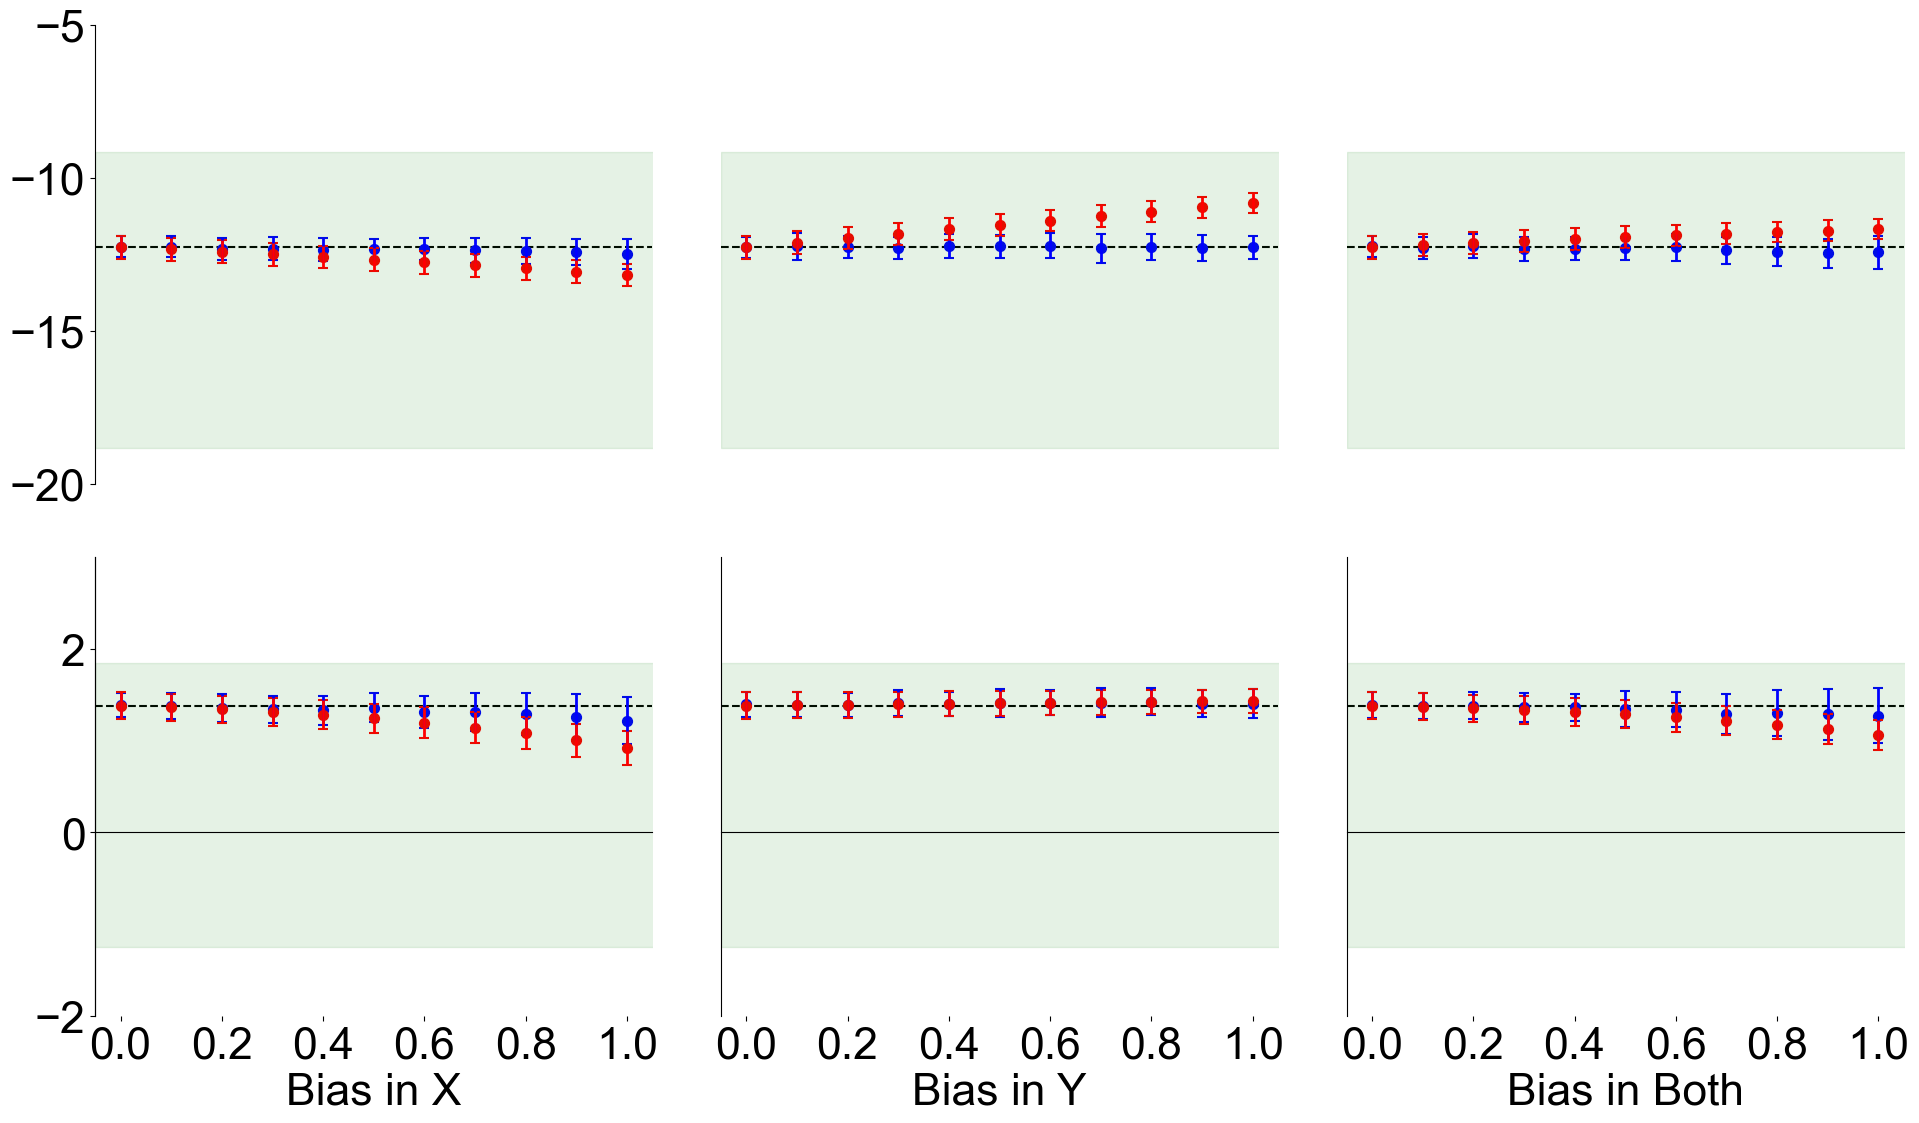

In [54]:
bias_factors = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
#bias_factors = np.array([0])
alpha = 0.05

# Classical CI
np.random.seed(seed=0)
calibration_indices = np.random.choice(np.arange(0, len(data)), size=500, replace=True)
X = truth_X[calibration_indices]
Y = truth_Y[calibration_indices]
classical_ci = classical_ols_ci(X, Y, alpha=alpha)
classical_estimate = 0.5*(classical_ci[0] + classical_ci[1])
classical_width = (classical_ci[1] - classical_ci[0])
print("Classical estimate then width:")
print(classical_estimate)
print(classical_width)

fig = plt.figure(figsize=(20, 12))
for j, error_mode in enumerate(['X', 'Y', 'Both']):
    ppi_estimates = []
    ppi_widths = []
    map_only_estimates = []
    map_only_widths = []

    for bias_factor in bias_factors:
        preds_X = truth_X.copy()
        preds_X[:, -1] = bias_factor*X_bias_fit + (1-bias_factor)*truth_X[:, -1]

        preds_Y = bias_factor*Y_bias_fit + (1-bias_factor)*truth_Y[:, 0]
        
        if error_mode == 'X':
            # ERROR IN X
            Xhat = preds_X[calibration_indices]
            Xhat_unlabeled = preds_X
            Yhat = truth_Y[calibration_indices]
            Yhat_unlabeled = truth_Y
        if error_mode == 'Y':
            # ERROR IN Y
            Xhat = truth_X[calibration_indices]
            Xhat_unlabeled = truth_X
            Yhat = preds_Y[calibration_indices]
            Yhat_unlabeled = preds_Y
        if error_mode == 'Both':
            # ERROR IN Both
            Xhat = preds_X[calibration_indices]
            Xhat_unlabeled = preds_X
            Yhat = preds_Y[calibration_indices]
            Yhat_unlabeled = preds_Y
            
        df = run_ppi_linear_regression(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, alpha)
        ppi_estimates.append(df.loc[df['method']=='PPI']['estimate'].mean())
        ppi_widths.append(df.loc[df['method']=='PPI']['width'].mean())
        map_only_estimates.append(df.loc[df['method']=='Map-only']['estimate'].mean())
        map_only_widths.append(df.loc[df['method']=='Map-only']['width'].mean())
    
    ppi_estimates = np.array(ppi_estimates)
    ppi_widths = np.array(ppi_widths)
    map_only_estimates = np.array(map_only_estimates)
    map_only_widths = np.array(map_only_widths)
    print(error_mode)
    print("PPI estimates then widths:")
    print(ppi_estimates)
    print(ppi_widths)
    print("Map only estimates then widths:")
    print(map_only_estimates)
    print(map_only_widths)
    
    for k in [1, 2]:
        subplot = fig.add_subplot(231+j+3*(k-1))
        #ax = plt.gca()
        subplot.spines['top'].set_visible(False)
        subplot.spines['right'].set_visible(False)

        subplot.axhline(true_coeff[k], color ='black', linestyle='--', label='True coefficient', zorder=0)

        subplot.plot([], '-o', color='blue', label='PPI')
        subplot.plot([], '-o', color='red', label='Map-only')

        for i, prob in enumerate(bias_factors):
            ymin = (ppi_estimates[:, k]-np.array(ppi_widths[:, k])/2)[i]
            ymax = (ppi_estimates[:, k]+np.array(ppi_widths[:, k])/2)[i]
            subplot.vlines(x=prob, ymin=ymin, ymax=ymax, color="blue", linewidth=2)
        subplot.scatter(bias_factors, ppi_estimates[:, k], color='blue', s=50)
        subplot.scatter(bias_factors, ppi_estimates[:, k]-np.array(ppi_widths[:, k])/2, color='blue', marker='_', s=50)
        subplot.scatter(bias_factors, ppi_estimates[:, k]+np.array(ppi_widths[:, k])/2, color='blue', marker='_', s=50)

        for i, prob in enumerate(bias_factors):
            ymin = (map_only_estimates[:, k]-np.array(map_only_widths[:, k])/2)[i]
            ymax = (map_only_estimates[:, k]+np.array(map_only_widths[:, k])/2)[i]
            subplot.vlines(x=prob, ymin=ymin, ymax=ymax, color="red", linewidth=2)
        subplot.scatter(bias_factors, map_only_estimates[:, k], color='red', s=50)
        subplot.scatter(bias_factors, map_only_estimates[:, k]-np.array(map_only_widths[:, k])/2, color='red', marker='_', s=50)
        subplot.scatter(bias_factors, map_only_estimates[:, k]+np.array(map_only_widths[:, k])/2, color='red', marker='_', s=50)

        subplot.fill_between(np.arange(-0.05, 1.2, 0.1), classical_estimate[k]-classical_width[k]/2, classical_estimate[k]+classical_width[k]/2, color='green', alpha=0.1, label='GT-only')

        #plt.legend(bbox_to_anchor=(1.5, 1.5))
        
        subplot.set_xlim([-0.05, 1.05])
        if k==2: # population
            subplot.set_xticks(np.arange(0, 1.05, 0.2))
            subplot.set_ylim([-2, 3])
            subplot.set_yticks(np.arange(-2, 3, 2))
            subplot.set_xlabel(f"Bias in {error_mode}")
            
            subplot.spines['bottom'].set_visible(False)
            ax = subplot.twiny()
            ax.spines['bottom'].set_position(('data', 0))
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_xticks([])
            
        else:
            subplot.set_ylim([-20, -5])
            subplot.set_yticks(np.arange(-20, -4, 5))
            subplot.spines['bottom'].set_visible(False)
            subplot.set_xticks([])
            
        if j!=0:
            subplot.spines['left'].set_visible(False)
            subplot.yaxis.set_visible(False)
        
        '''
        if j==0:
            if k==1:
                subplot.set_ylabel("Elevation Coeff")
            else:
                subplot.set_ylabel("Population Coeff")
        else:
            subplot.spines['left'].set_visible(False)
            subplot.yaxis.set_visible(False)
        '''

plt.tight_layout()
plt.savefig('output_images/forest_cover_bias_quadratic.png', dpi=300, bbox_inches='tight')
plt.show()

# Add bias (linear fit)

We explore another type of bias. We first fit a linear regression relating a variable to its corresponding MOSAIKS map product values. We then create a biased simulated map product by linearly interpolating between the regression predictions and ground truth values. We vary the linear interpolation parameter to control the amount of bias. We do this for population (X), forest cover (Y), or both. 

We print out the GT-only (classical), map-only, and PPI estimates and confidence interval widths. We also print the R^2 coefficient of determination between the simulated map product and the ground truth. 

In [55]:
# Fit line for X_population
p = np.polyfit(truth_X[:, -1], map_X[:, -1], deg=1)
print(p)
X_bias_fit = np.poly1d(p)(truth_X[:, -1])
print(X_bias_fit)
print(np.corrcoef(truth_X[:, -1], map_X[:, -1])**2)
print(np.corrcoef(truth_X[:, -1], X_bias_fit)**2)

[0.73257175 0.48218121]
[0.69534832 0.53350418 1.7801407  ... 3.50082569 1.17452882 2.0004747 ]
[[1.         0.72604542]
 [0.72604542 1.        ]]
[[1. 1.]
 [1. 1.]]


In [56]:
# Fit line for Y
p = np.polyfit(truth_Y[:, 0], map_Y[:, 0], deg=1)
print(p)
Y_bias_fit = np.poly1d(p)(truth_Y[:, 0])
print(Y_bias_fit)
print(np.corrcoef(truth_Y[:, 0], map_Y[:, 0])**2)
print(np.corrcoef(truth_Y[:, 0], Y_bias_fit)**2)

[0.88201919 3.6639001 ]
[ 3.6639001   3.6639001  32.33938098 ...  6.26321064  3.73804457
 66.60998355]
[[1.         0.91254874]
 [0.91254874 1.        ]]
[[1. 1.]
 [1. 1.]]


Classical estimate then width:
[ 33.60350517 -13.98925325   0.29617747]
[11.72985261  9.68382557  3.08682222]


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 51.05it/s]


X
PPI estimates then widths:
[[ 31.80043704 -12.24495648   1.38488822]
 [ 31.76049792 -12.24091694   1.38104132]
 [ 31.81719223 -12.31351728   1.37283317]
 [ 31.89678681 -12.26825884   1.36898595]
 [ 31.84969004 -12.29857049   1.37211189]
 [ 31.8051021  -12.2589672    1.39762797]
 [ 31.81960622 -12.23162115   1.37547017]
 [ 31.76929645 -12.24967249   1.38794677]
 [ 31.79121467 -12.24802729   1.35859255]
 [ 31.75228061 -12.23941498   1.39653272]
 [ 31.78374958 -12.25651871   1.38388703]]
[[0.99985565 0.70883929 0.25424586]
 [0.98291684 0.68429486 0.26307028]
 [1.03353758 0.68507396 0.30417959]
 [1.08247037 0.70962174 0.27326168]
 [1.02642267 0.71684444 0.30278425]
 [0.95302817 0.65724557 0.28485995]
 [0.94395937 0.5899865  0.26840476]
 [0.93560508 0.71763433 0.25516216]
 [0.88697042 0.71555932 0.29515084]
 [1.01541262 0.71745792 0.28544065]
 [1.07955764 0.84560245 0.28629119]]
Map only estimates then widths:
[[ 31.80598858 -12.25842547   1.37923979]
 [ 31.73765684 -12.25842547   1.41713

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 54.60it/s]


Y
PPI estimates then widths:
[[ 31.7681106  -12.2612145    1.39390739]
 [ 31.75537214 -12.24198629   1.38496444]
 [ 31.81562299 -12.2645931    1.37412455]
 [ 31.77799859 -12.30572965   1.39812704]
 [ 31.75848098 -12.22807264   1.38848616]
 [ 31.83217193 -12.24807097   1.37877753]
 [ 31.72393505 -12.22761753   1.38600827]
 [ 31.79167934 -12.30159316   1.38696264]
 [ 31.77776192 -12.26860892   1.38321847]
 [ 31.81690976 -12.28497374   1.37526447]
 [ 31.83419899 -12.23089236   1.36815698]]
[[0.98669615 0.6927423  0.26888102]
 [1.15960647 0.85921612 0.26937133]
 [0.84835259 0.70888436 0.26485552]
 [0.88732402 0.69881797 0.28171624]
 [1.00954858 0.73838095 0.26803393]
 [0.97316114 0.71236623 0.27634333]
 [0.89142682 0.73563331 0.24430944]
 [1.0197077  0.88415324 0.29783704]
 [1.00400458 0.76809636 0.2835962 ]
 [1.09805996 0.74390757 0.26811695]
 [1.01143995 0.69916205 0.28872721]]
Map only estimates then widths:
[[ 31.80598858 -12.25842547   1.37923979]
 [ 31.79712894 -12.11379957   1.36296

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 53.12it/s]


Both
PPI estimates then widths:
[[ 31.77691888 -12.23932504   1.38553444]
 [ 31.77838563 -12.26893659   1.37315393]
 [ 31.75682061 -12.19726217   1.38159442]
 [ 31.7963531  -12.27427819   1.37351739]
 [ 31.78036479 -12.25093281   1.37467467]
 [ 31.83614671 -12.26027538   1.37098598]
 [ 31.7904621  -12.23116129   1.38011173]
 [ 31.82053783 -12.23461976   1.36612067]
 [ 31.78720187 -12.26006912   1.396314  ]
 [ 31.82070591 -12.26091948   1.37808779]
 [ 31.83142604 -12.27142625   1.38576605]]
[[1.09696618 0.67905067 0.2832796 ]
 [0.99258944 0.7048156  0.27877142]
 [1.03660714 0.75417809 0.28414299]
 [1.06336814 0.76505098 0.29855367]
 [1.07628016 0.72911934 0.28465166]
 [1.03173255 0.78553434 0.28338841]
 [0.99892489 0.80031671 0.25448111]
 [1.02403644 0.77691703 0.29253814]
 [1.05478882 0.81122363 0.28441034]
 [0.99241538 0.72375027 0.25555076]
 [1.09262702 0.75469246 0.25762782]]
Map only estimates then widths:
[[ 31.80598858 -12.25842547   1.37923979]
 [ 31.72960339 -12.11379957   1.40

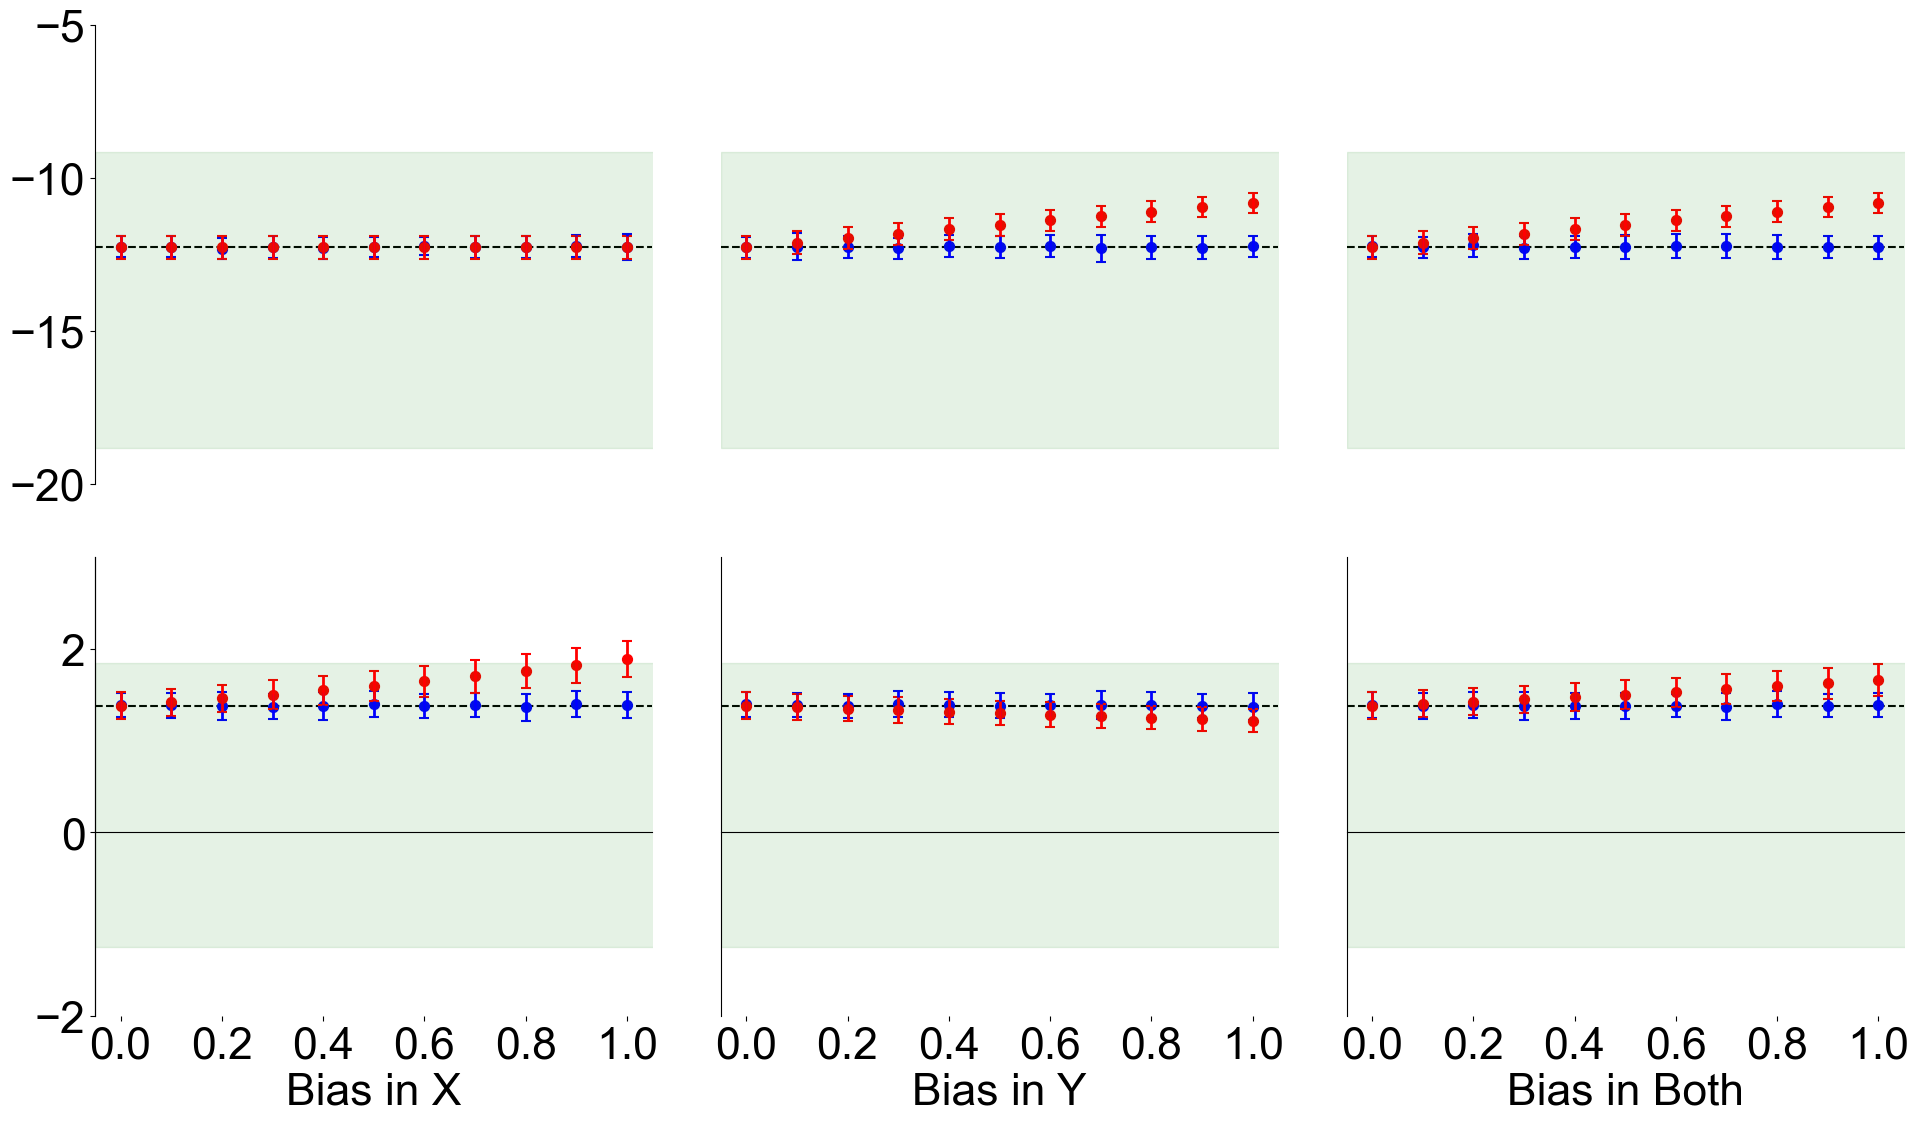

In [57]:
bias_factors = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
#bias_factors = np.array([0])
alpha = 0.05

# Classical CI
np.random.seed(seed=0)
calibration_indices = np.random.choice(np.arange(0, len(data)), size=500, replace=True)
X = truth_X[calibration_indices]
Y = truth_Y[calibration_indices]
classical_ci = classical_ols_ci(X, Y, alpha=alpha)
classical_estimate = 0.5*(classical_ci[0] + classical_ci[1])
classical_width = (classical_ci[1] - classical_ci[0])
print("Classical estimate then width:")
print(classical_estimate)
print(classical_width)

fig = plt.figure(figsize=(20, 12))
for j, error_mode in enumerate(['X', 'Y', 'Both']):
    ppi_estimates = []
    ppi_widths = []
    map_only_estimates = []
    map_only_widths = []

    for bias_factor in bias_factors:
        preds_X = truth_X.copy()
        preds_X[:, -1] = bias_factor*X_bias_fit + (1-bias_factor)*truth_X[:, -1]

        preds_Y = bias_factor*Y_bias_fit + (1-bias_factor)*truth_Y[:, 0]
        
        if error_mode == 'X':
            # ERROR IN X
            Xhat = preds_X[calibration_indices]
            Xhat_unlabeled = preds_X
            Yhat = truth_Y[calibration_indices]
            Yhat_unlabeled = truth_Y
        if error_mode == 'Y':
            # ERROR IN Y
            Xhat = truth_X[calibration_indices]
            Xhat_unlabeled = truth_X
            Yhat = preds_Y[calibration_indices]
            Yhat_unlabeled = preds_Y
        if error_mode == 'Both':
            # ERROR IN Both
            Xhat = preds_X[calibration_indices]
            Xhat_unlabeled = preds_X
            Yhat = preds_Y[calibration_indices]
            Yhat_unlabeled = preds_Y
            
        df = run_ppi_linear_regression(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, alpha)
        ppi_estimates.append(df.loc[df['method']=='PPI']['estimate'].mean())
        ppi_widths.append(df.loc[df['method']=='PPI']['width'].mean())
        map_only_estimates.append(df.loc[df['method']=='Map-only']['estimate'].mean())
        map_only_widths.append(df.loc[df['method']=='Map-only']['width'].mean())
    
    ppi_estimates = np.array(ppi_estimates)
    ppi_widths = np.array(ppi_widths)
    map_only_estimates = np.array(map_only_estimates)
    map_only_widths = np.array(map_only_widths)
    print(error_mode)
    print("PPI estimates then widths:")
    print(ppi_estimates)
    print(ppi_widths)
    print("Map only estimates then widths:")
    print(map_only_estimates)
    print(map_only_widths)
    
    for k in [1, 2]:
        subplot = fig.add_subplot(231+j+3*(k-1))
        #ax = plt.gca()
        subplot.spines['top'].set_visible(False)
        subplot.spines['right'].set_visible(False)

        subplot.axhline(true_coeff[k], color ='black', linestyle='--', label='True coefficient', zorder=0)

        subplot.plot([], '-o', color='blue', label='PPI')
        subplot.plot([], '-o', color='red', label='Map-only')

        for i, prob in enumerate(bias_factors):
            ymin = (ppi_estimates[:, k]-np.array(ppi_widths[:, k])/2)[i]
            ymax = (ppi_estimates[:, k]+np.array(ppi_widths[:, k])/2)[i]
            subplot.vlines(x=prob, ymin=ymin, ymax=ymax, color="blue", linewidth=2)
        subplot.scatter(bias_factors, ppi_estimates[:, k], color='blue', s=50)
        subplot.scatter(bias_factors, ppi_estimates[:, k]-np.array(ppi_widths[:, k])/2, color='blue', marker='_', s=50)
        subplot.scatter(bias_factors, ppi_estimates[:, k]+np.array(ppi_widths[:, k])/2, color='blue', marker='_', s=50)

        for i, prob in enumerate(bias_factors):
            ymin = (map_only_estimates[:, k]-np.array(map_only_widths[:, k])/2)[i]
            ymax = (map_only_estimates[:, k]+np.array(map_only_widths[:, k])/2)[i]
            subplot.vlines(x=prob, ymin=ymin, ymax=ymax, color="red", linewidth=2)
        subplot.scatter(bias_factors, map_only_estimates[:, k], color='red', s=50)
        subplot.scatter(bias_factors, map_only_estimates[:, k]-np.array(map_only_widths[:, k])/2, color='red', marker='_', s=50)
        subplot.scatter(bias_factors, map_only_estimates[:, k]+np.array(map_only_widths[:, k])/2, color='red', marker='_', s=50)

        subplot.fill_between(np.arange(-0.05, 1.2, 0.1), classical_estimate[k]-classical_width[k]/2, classical_estimate[k]+classical_width[k]/2, color='green', alpha=0.1, label='GT-only')

        #plt.legend(bbox_to_anchor=(1.5, 1.5))
        
        subplot.set_xlim([-0.05, 1.05])
        if k==2: # population
            subplot.set_xticks(np.arange(0, 1.05, 0.2))
            subplot.set_ylim([-2, 3])
            subplot.set_yticks(np.arange(-2, 3, 2))
            subplot.set_xlabel(f"Bias in {error_mode}")
            
            subplot.spines['bottom'].set_visible(False)
            ax = subplot.twiny()
            ax.spines['bottom'].set_position(('data', 0))
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_xticks([])
            
        else:
            subplot.set_ylim([-20, -5])
            subplot.set_yticks(np.arange(-20, -4, 5))
            subplot.spines['bottom'].set_visible(False)
            subplot.set_xticks([])
            
        if j!=0:
            subplot.spines['left'].set_visible(False)
            subplot.yaxis.set_visible(False)
        
        '''
        if j==0:
            if k==1:
                subplot.set_ylabel("Elevation Coeff")
            else:
                subplot.set_ylabel("Population Coeff")
        else:
            subplot.spines['left'].set_visible(False)
            subplot.yaxis.set_visible(False)
        '''

plt.tight_layout()
plt.savefig('output_images/forest_cover_bias_linear.png', dpi=300, bbox_inches='tight')
plt.show()

# Add bias (square root fit)

We explore another type of bias. We first fit a square root regression relating a variable to its corresponding MOSAIKS map product values. We then create a biased simulated map product by linearly interpolating between the regression predictions and ground truth values. We vary the linear interpolation parameter to control the amount of bias. We do this for population (X), forest cover (Y), or both. 

We print out the GT-only (classical), map-only, and PPI estimates and confidence interval widths. We also print the R^2 coefficient of determination between the simulated map product and the ground truth. 

In [48]:
# Fit square root for X_population
p = np.polyfit(np.sqrt(truth_X[:, -1]), map_X[:, -1], deg=1)
print(p)
X_bias_fit = np.poly1d(p)(np.sqrt(truth_X[:, -1]))
print(X_bias_fit)
print(np.corrcoef(truth_X[:, -1], map_X[:, -1])**2)
print(np.corrcoef(truth_X[:, -1], X_bias_fit)**2)
print(np.corrcoef(map_X[:, -1], X_bias_fit)**2)

[ 1.73710164 -0.2182061 ]
[0.71883846 0.24158021 2.09402223 ... 3.30798733 1.47053179 2.28258845]
[[1.         0.72604542]
 [0.72604542 1.        ]]
[[1.         0.91889514]
 [0.91889514 1.        ]]
[[1.         0.63043383]
 [0.63043383 1.        ]]


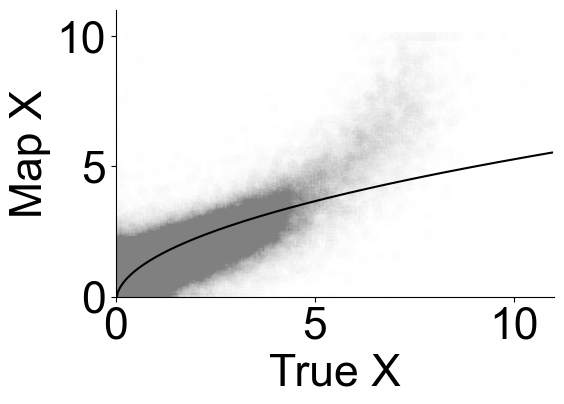

In [49]:
plt.rcParams["font.sans-serif"] = "Arial"

plt.rc('font', size=32)          
plt.rc('axes', titlesize=32)     
plt.rc('axes', labelsize=32)    
plt.rc('xtick', labelsize=32)    
plt.rc('ytick', labelsize=32)    
plt.rc('legend', fontsize=32)    
plt.rc('figure', titlesize=32)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x_values = np.arange(0, 11, .05)
plt.plot(x_values, np.poly1d(p)(np.sqrt(x_values)), c='black')
#plt.plot(x_values, x_values, c='black')
plt.scatter(truth_X[:, -1], map_X[:, -1], alpha=0.004, c='grey', s=40)
plt.xlabel("True X")
plt.ylabel("Map X")
plt.xlim([0, 11])
plt.ylim([0, 11])
plt.tight_layout()
plt.savefig('output_images/population_square_root_fit.png', dpi=300, bbox_inches='tight')
plt.show()

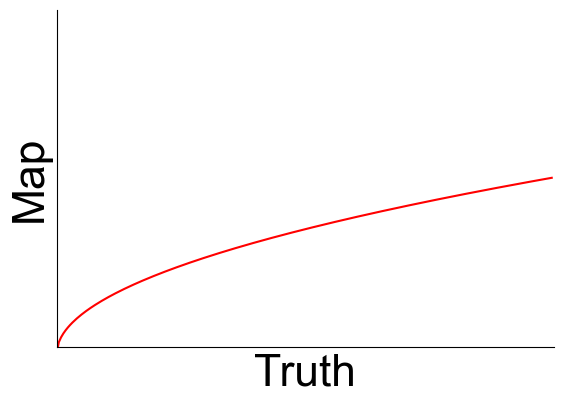

In [50]:
plt.rcParams["font.sans-serif"] = "Arial"

plt.rc('font', size=32)          
plt.rc('axes', titlesize=32)     
plt.rc('axes', labelsize=32)    
plt.rc('xtick', labelsize=32)    
plt.rc('ytick', labelsize=32)    
plt.rc('legend', fontsize=32)    
plt.rc('figure', titlesize=32)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x_values = np.arange(0, 11, .05)
plt.plot(x_values, np.poly1d(p)(np.sqrt(x_values)), c='red')
#plt.plot(x_values, x_values, c='black')
plt.xlabel("Truth")
plt.ylabel("Map")
plt.xlim([0, 11])
plt.ylim([0, 11])
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('output_images/bias_image.png', dpi=300, bbox_inches='tight')
plt.show()

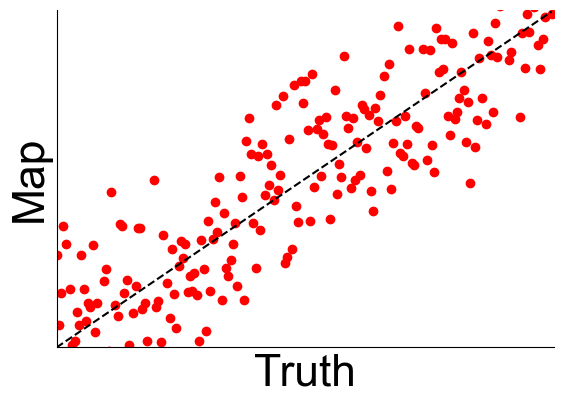

In [51]:
plt.rcParams["font.sans-serif"] = "Arial"

plt.rc('font', size=32)          
plt.rc('axes', titlesize=32)     
plt.rc('axes', labelsize=32)    
plt.rc('xtick', labelsize=32)    
plt.rc('ytick', labelsize=32)    
plt.rc('legend', fontsize=32)    
plt.rc('figure', titlesize=32)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x_values = np.arange(0, 11, .05)
plt.plot(x_values, x_values, c='black', ls='--')
X_std = np.std(truth_X, axis=0)[-1] # standard deviation of population covariate
np.random.seed(seed=0)
y_values = x_values + np.random.normal(0, X_std, size=len(x_values))

plt.scatter(x_values, y_values, c='red')
plt.xlabel("Truth")
plt.ylabel("Map")
plt.xlim([0, 11])
plt.ylim([0, 11])
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig('output_images/noise_image.png', dpi=300, bbox_inches='tight')
plt.show()

In [52]:
# Fit square root for Y
p = np.polyfit(np.sqrt(truth_Y[:, 0]), map_Y[:, 0], deg=1)
print(p)
Y_bias_fit = np.poly1d(p)(np.sqrt(truth_Y[:, 0]))
print(Y_bias_fit)
print(np.corrcoef(truth_Y[:, 0], map_Y[:, 0])**2)
print(np.corrcoef(truth_Y[:, 0], Y_bias_fit)**2)

[ 7.90121095 -3.19706724]
[-3.19706724 -3.19706724 41.85450957 ... 10.36680608 -0.90623112
 63.55104657]
[[1.         0.91254874]
 [0.91254874 1.        ]]
[[1.         0.93350989]
 [0.93350989 1.        ]]


Classical estimate then width:
[ 33.60350517 -13.98925325   0.29617747]
[11.72985261  9.68382557  3.08682222]
ERROR IN X:


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 54.17it/s]


c: 0.0 | R2 X: 1.0 | R2 Y: 1.0 | PPI estimates: [ 31.80043704 -12.24495648   1.38488822] | PPI widths: [0.99985565 0.70883929 0.25424586] | Map-only estimates: [ 31.80598858 -12.25842547   1.37923979] | Map-only widths: [1.02454054 0.7501571  0.28631906]


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 58.21it/s]


c: 0.1 | R2 X: 0.9992133858025928 | R2 Y: 1.0 | PPI estimates: [ 31.73062545 -12.22552087   1.39097859] | PPI widths: [0.98681105 0.68989193 0.26351695] | Map-only estimates: [ 31.51482714 -12.14429963   1.50364462] | Map-only widths: [1.04376831 0.75347763 0.29837389]


...

c: 0.8 | R2 X: 0.9496566913659364 | R2 Y: 0.9502652854431652 | PPI estimates: [ 31.61688226 -11.92793586   1.5638047 ] | PPI widths: [2.61110779 1.9480237  0.91167756] | Map-only estimates: [25.52974643 -9.7554948   4.28579077] | Map-only widths: [1.09495917 0.75993014 0.36805915]


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 53.52it/s]


c: 0.9 | R2 X: 0.9362842500100125 | R2 Y: 0.937054501889006 | PPI estimates: [ 31.56102566 -11.92000405   1.60869993] | PPI widths: [3.24384034 2.15564766 0.91660282] | Map-only estimates: [24.35947114 -9.33578116  4.8274506 ] | Map-only widths: [1.11187089 0.76417112 0.38032498]


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 53.67it/s]


c: 1.0 | R2 X: 0.9213385802592753 | R2 Y: 0.9222895085049456 | PPI estimates: [ 31.61760706 -11.92992712   1.59299576] | PPI widths: [3.34537679 2.27644066 1.15671901] | Map-only estimates: [23.09171559 -8.89394258  5.41566509] | Map-only widths: [1.13048971 0.76905319 0.39291649]


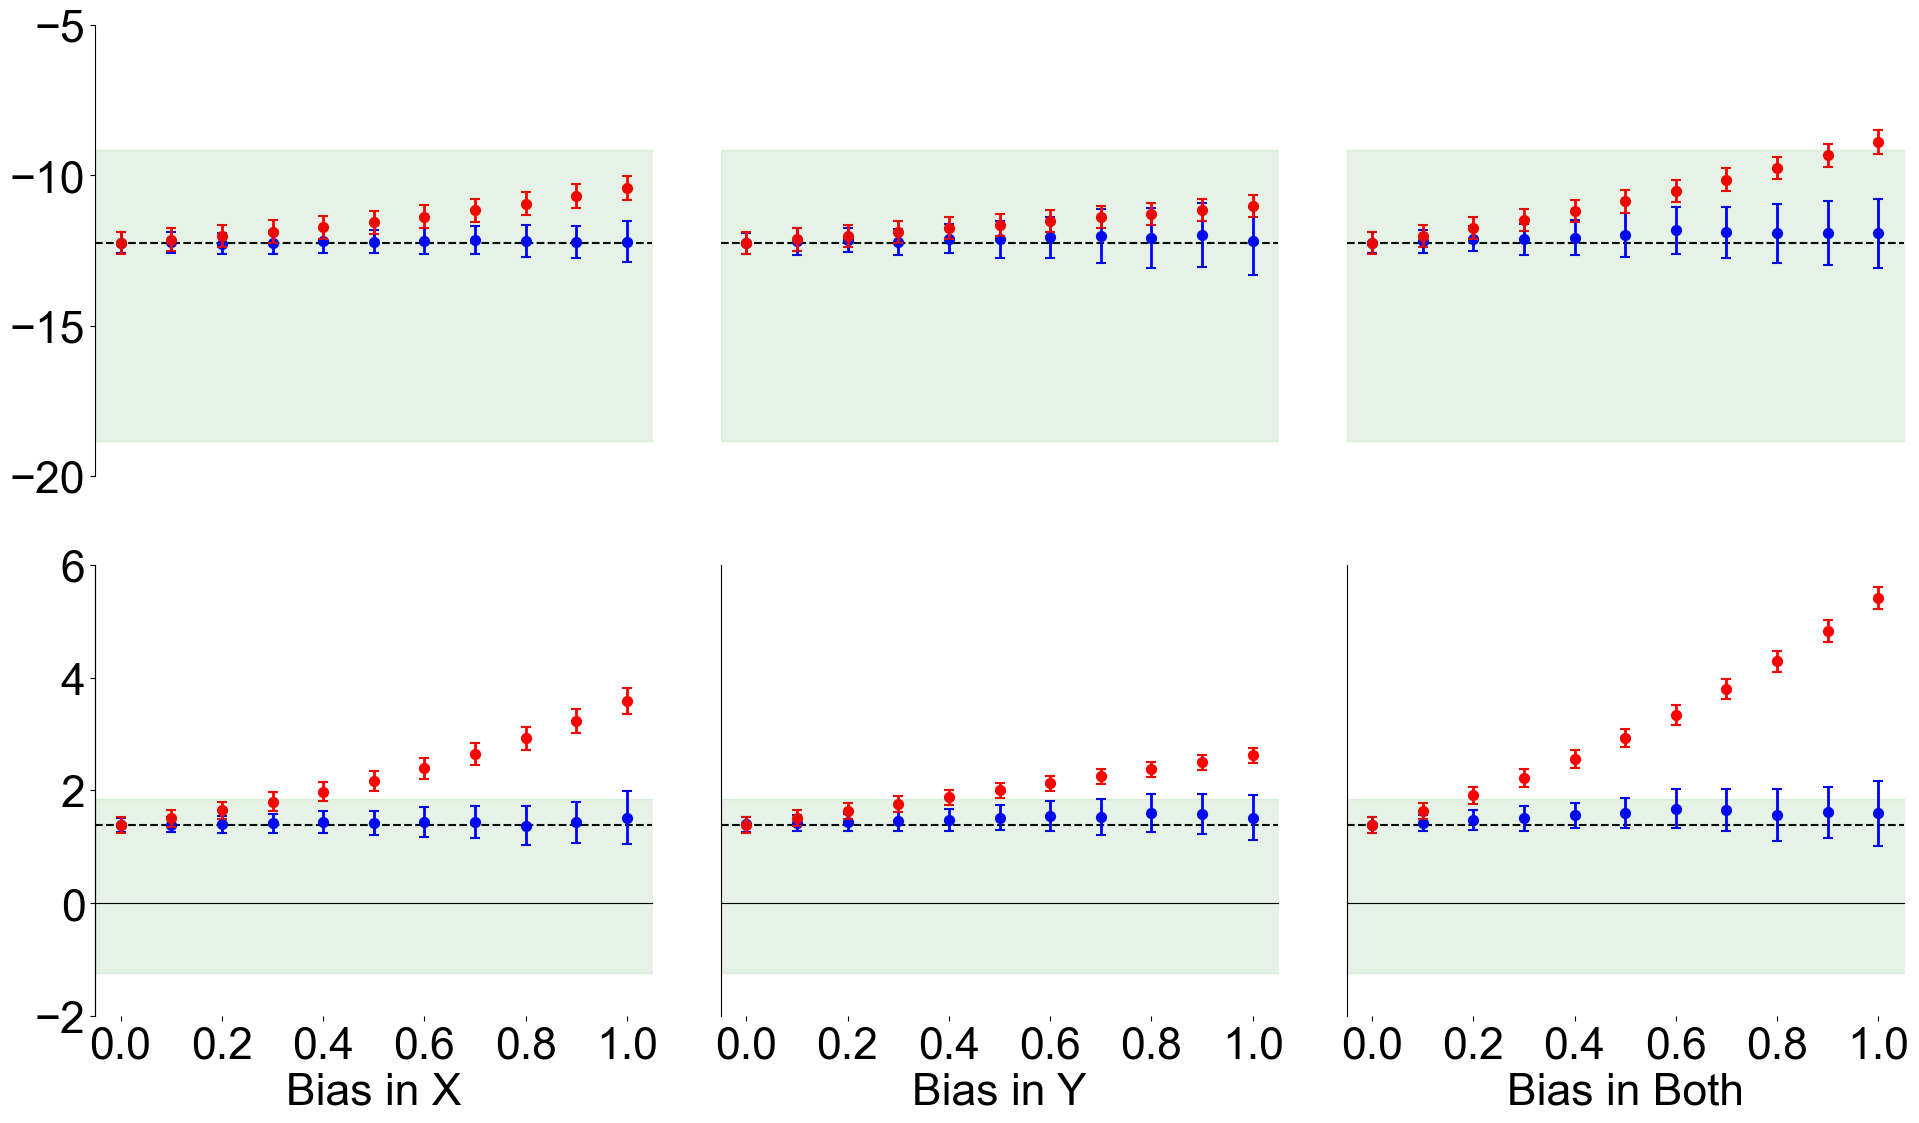

In [54]:
bias_factors = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
#bias_factors = np.array([0])
alpha = 0.05

# Classical CI
np.random.seed(seed=0)
calibration_indices = np.random.choice(np.arange(0, len(data)), size=500, replace=True)
X = truth_X[calibration_indices]
Y = truth_Y[calibration_indices]
classical_ci = classical_ols_ci(X, Y, alpha=alpha)
classical_estimate = 0.5*(classical_ci[0] + classical_ci[1])
classical_width = (classical_ci[1] - classical_ci[0])
print("Classical estimate then width:")
print(classical_estimate)
print(classical_width)

fig = plt.figure(figsize=(20, 12))
for j, error_mode in enumerate(['X', 'Y', 'Both']):
    print(f"ERROR IN {error_mode}:")
    
    ppi_estimates = []
    ppi_widths = []
    map_only_estimates = []
    map_only_widths = []

    for bias_factor in bias_factors:
        preds_X = truth_X.copy()
        preds_X[:, -1] = bias_factor*X_bias_fit + (1-bias_factor)*truth_X[:, -1]

        preds_Y = bias_factor*Y_bias_fit + (1-bias_factor)*truth_Y[:, 0]
        
        if error_mode == 'X':
            # ERROR IN X
            Xhat = preds_X[calibration_indices]
            Xhat_unlabeled = preds_X
            Yhat = truth_Y[calibration_indices]
            Yhat_unlabeled = truth_Y
        if error_mode == 'Y':
            # ERROR IN Y
            Xhat = truth_X[calibration_indices]
            Xhat_unlabeled = truth_X
            Yhat = preds_Y[calibration_indices]
            Yhat_unlabeled = preds_Y
        if error_mode == 'Both':
            # ERROR IN Both
            Xhat = preds_X[calibration_indices]
            Xhat_unlabeled = preds_X
            Yhat = preds_Y[calibration_indices]
            Yhat_unlabeled = preds_Y
            
        df = run_ppi_linear_regression(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, alpha)
        ppi_estimates.append(df.loc[df['method']=='PPI']['estimate'].mean())
        ppi_widths.append(df.loc[df['method']=='PPI']['width'].mean())
        map_only_estimates.append(df.loc[df['method']=='Map-only']['estimate'].mean())
        map_only_widths.append(df.loc[df['method']=='Map-only']['width'].mean())
        
        print("c:", bias_factor,
              "| R2 X:", r2_score(truth_X, Xhat_unlabeled),
              "| R2 Y:", r2_score(truth_Y, Yhat_unlabeled),
              "| PPI estimates:", ppi_estimates[-1], "| PPI widths:", ppi_widths[-1], 
              "| Map-only estimates:", map_only_estimates[-1], "| Map-only widths:", map_only_widths[-1])
    
    ppi_estimates = np.array(ppi_estimates)
    ppi_widths = np.array(ppi_widths)
    map_only_estimates = np.array(map_only_estimates)
    map_only_widths = np.array(map_only_widths)
    
    for k in [1, 2]:
        subplot = fig.add_subplot(231+j+3*(k-1))
        #ax = plt.gca()
        subplot.spines['top'].set_visible(False)
        subplot.spines['right'].set_visible(False)

        subplot.axhline(true_coeff[k], color ='black', linestyle='--', label='True coefficient', zorder=0)

        subplot.plot([], '-o', color='blue', label='PPI')
        subplot.plot([], '-o', color='red', label='Map-only')

        for i, prob in enumerate(bias_factors):
            ymin = (ppi_estimates[:, k]-np.array(ppi_widths[:, k])/2)[i]
            ymax = (ppi_estimates[:, k]+np.array(ppi_widths[:, k])/2)[i]
            subplot.vlines(x=prob, ymin=ymin, ymax=ymax, color="blue", linewidth=2)
        subplot.scatter(bias_factors, ppi_estimates[:, k], color='blue', s=50)
        subplot.scatter(bias_factors, ppi_estimates[:, k]-np.array(ppi_widths[:, k])/2, color='blue', marker='_', s=50)
        subplot.scatter(bias_factors, ppi_estimates[:, k]+np.array(ppi_widths[:, k])/2, color='blue', marker='_', s=50)

        for i, prob in enumerate(bias_factors):
            ymin = (map_only_estimates[:, k]-np.array(map_only_widths[:, k])/2)[i]
            ymax = (map_only_estimates[:, k]+np.array(map_only_widths[:, k])/2)[i]
            subplot.vlines(x=prob, ymin=ymin, ymax=ymax, color="red", linewidth=2)
        subplot.scatter(bias_factors, map_only_estimates[:, k], color='red', s=50)
        subplot.scatter(bias_factors, map_only_estimates[:, k]-np.array(map_only_widths[:, k])/2, color='red', marker='_', s=50)
        subplot.scatter(bias_factors, map_only_estimates[:, k]+np.array(map_only_widths[:, k])/2, color='red', marker='_', s=50)

        subplot.fill_between(np.arange(-0.05, 1.2, 0.1), classical_estimate[k]-classical_width[k]/2, classical_estimate[k]+classical_width[k]/2, color='green', alpha=0.1, label='GT-only')

        #plt.legend(bbox_to_anchor=(1.5, 1.5))
        
        subplot.set_xlim([-0.05, 1.05])
        if k==2: # population
            subplot.set_xticks(np.arange(0, 1.05, 0.2))
            subplot.set_ylim([-2, 6])
            subplot.set_yticks(np.arange(-2, 7, 2))
            subplot.set_xlabel(f"Bias in {error_mode}")
            
            subplot.spines['bottom'].set_visible(False)
            ax = subplot.twiny()
            ax.spines['bottom'].set_position(('data', 0))
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_xticks([])
            
        else:
            subplot.set_ylim([-20, -5])
            subplot.set_yticks(np.arange(-20, -4, 5))
            subplot.spines['bottom'].set_visible(False)
            subplot.set_xticks([])
            
        if j!=0:
            subplot.spines['left'].set_visible(False)
            subplot.yaxis.set_visible(False)
        
        '''
        if j==0:
            if k==1:
                subplot.set_ylabel("Elevation Coeff")
            else:
                subplot.set_ylabel("Population Coeff")
        else:
            subplot.spines['left'].set_visible(False)
            subplot.yaxis.set_visible(False)
        '''

plt.tight_layout()
plt.savefig('output_images/forest_cover_bias_sqrt.png', dpi=300, bbox_inches='tight')
plt.show()